# Modelling Chronic Disease Burden from Area Level Determinants

### A study of 1,473 census tracts in the Washington metropolitan area, and of how much apparent predictive power in model based health data is real

Weston Nyabeze · MS Business Analytics and Artificial Intelligence, Kogod School of Business,
American University · 31 August 2026

---

#### Abstract

**Background.** Small area health estimates such as the CDC PLACES programme have made it possible to
model chronic disease at neighbourhood resolution. Whether the resulting models carry epidemiological
information, or mainly reproduce the statistical machinery that generated the estimates, has received
little attention.

**Objective.** To quantify how much of the tract level variation in chronic disease burden across the
Washington metropolitan area is explained by modifiable behavioural, healthcare access and social
risk factors, and to establish how much of that explanation survives scrutiny.

**Methods.** A Chronic Disease Burden Index was constructed from six clinician diagnosed conditions
across 1,473 census tracts and validated psychometrically. Nineteen determinants in four conceptual
blocks were regressed on it using ordinary least squares, ridge, lasso, elastic net, random forest and
gradient boosting, evaluated under both random 10-fold and county blocked 5-fold cross validation.
Three independent diagnostics then tested whether the fit reflects signal or shared structure:
principal component analysis of the effective dimensionality of the data, pairwise redundancy among
predictors, and a placebo protocol using clinically unrelated measures.

**Results.** The outcome index is strongly unidimensional (Cronbach's alpha 0.966, first component
85.4 per cent of variance). Models fit it well: elastic net reaches an $R^2$ of 0.970 under random
folds and 0.947 under county blocking. That performance is largely structural. The 40 PLACES measures
have an effective dimensionality of four, the median determinant is predictable from the other
eighteen at an $R^2$ of 0.967, the maximum variance inflation factor is 1,244, and two principal
components of seventeen clinically unrelated measures predict the outcome at an $R^2$ of 0.932 under
county blocking. The full designed determinant set adds only 0.047 beyond that placebo.

**Conclusions.** Cross sectional models of PLACES estimates recover the demographic basis of the
underlying small area model far more than they recover disease aetiology. High $R^2$ values in this
setting should be treated as a diagnostic of shared structure rather than as evidence of explanatory
success. The placebo and blocking protocol used here is inexpensive and is recommended as a routine
check whenever model based small area estimates are used as both predictors and outcome.

**Keywords.** Small area estimation; spatial cross validation; multicollinearity; chronic disease;
social determinants of health; regularised regression.

---

## 1. Introduction

### 1.1 Background

Chronic conditions account for the majority of preventable death and health spending in the United
States, and their burden is not distributed evenly within cities. Two neighbourhoods a few miles apart
can differ severalfold in the share of adults living with diabetes or uncontrolled blood pressure.
The dominant explanation in the literature is contextual: features of the neighbourhood itself, its
food environment, its walkability, its healthcare supply and its concentration of material hardship,
shape the health of residents beyond individual characteristics (Diez Roux and Mair, 2010).

Testing that explanation at neighbourhood resolution has historically been impossible, because health
surveys are not large enough to produce stable estimates for small areas. The CDC PLACES programme
changed this. Using multilevel regression and poststratification, PLACES fits a model to Behavioral
Risk Factor Surveillance System responses with individual demographics, county poverty and geographic
random effects, then applies the fitted parameters to census population counts to produce modelled
prevalence for 40 health measures in every census tract in the country (Greenlund et al., 2022).

That construction is the reason this study exists. PLACES estimates are outputs of a statistical model,
not measurements. When a researcher regresses one PLACES measure on several others, both sides of the
equation descend from the same fitted model and the same demographic inputs. The resulting association
may be epidemiological, or it may be an artefact of shared parentage. Distinguishing the two is not a
side issue in this data; this study finds it is the central one.

### 1.2 Problem statement

An analyst asked to explain neighbourhood chronic disease from behavioural, access and social risk
using PLACES will obtain a very good fit and, on standard practice, will report it. This study asks
whether that fit means what it appears to mean, and what an analyst should do instead.

### 1.3 Research questions

1. Can a reliable, unidimensional measure of tract level chronic disease burden be constructed from
   PLACES, and which candidate conditions must be excluded for it to be valid?
2. How much variation in that measure is explained by behavioural, healthcare access and social risk
   determinants, and does the answer change when models are validated across held out counties rather
   than at random?
3. Do flexible machine learning models outperform regularised linear models on this problem?
4. How much of the explained variation is attributable to the shared modelling basis of the PLACES
   estimates rather than to the determinants themselves?
5. What is left unexplained, and what does its structure indicate?

### 1.4 Objectives

- **O1.** Construct and psychometrically validate a Chronic Disease Burden Index.
- **O2.** Estimate and compare six regression models under two cross validation regimes.
- **O3.** Decompose the explained variance across four conceptual determinant blocks.
- **O4.** Test the shared basis hypothesis with three independent diagnostics.
- **O5.** Characterise the residual spatial process and state what the models cannot do.

### 1.5 Contribution and scope

The study contributes a validated outcome instrument for the region, a comparison showing that
regularised linear models generalise across counties better than tree ensembles on near collinear
smooth predictors, and a reusable three part protocol for detecting circularity in small area health
modelling. Its principal finding is negative and is reported as such. The unit of analysis is the
census tract, all inference is ecological (Robinson, 1950), and the design uses one cross section of
one metropolitan area.

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold, GroupShuffleSplit, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error

import figures as figs
figs.apply_theme()

SEED = 1234568
np.random.seed(SEED)
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

df = pd.read_csv("data/processed/places_dmv_wide.csv")
print("tracts", len(df), "| jurisdictions", df.CountyFIPS.nunique(),
      "| residents", f"{df.TotalPopulation.sum():,}",
      "| adults 18+", f"{df.TotalPop18plus.sum():,}")

tracts 1473 | jurisdictions 24 | residents 6,371,256 | adults 18+ 4,928,692


## 2. Literature Review

### 2.1 Neighbourhood context and chronic disease

The contextual account of health inequality holds that place affects health through mechanisms not
reducible to the characteristics of the people living there. Diez Roux and Mair (2010) review the
evidence and identify the recurring difficulty: neighbourhood exposures are correlated with one
another and with individual disadvantage, so isolating any single pathway is hard. Material hardship
has the clearest evidence base, and Gundersen and Ziliak (2015) document consistent associations
between food insecurity and chronic disease across a range of designs, while noting that reverse
causation is difficult to exclude.

### 2.2 Small area estimation and its consequences for inference

PLACES uses multilevel regression and poststratification: a multilevel logistic model is fitted to
survey responses with individual demographics, county poverty and geographic random effects, and the
fitted parameters are then applied to census population strata (Greenlund et al., 2022). The programme
reports strong correlation between its estimates and direct survey estimates at state, county and city
level, and cautions that agreement varies by measure and geography.

The methodological consequence has received less attention than the validation. Because every measure
is generated from the same covariates through the same framework, tract estimates of different
conditions are functions of a common, low dimensional demographic input, and any regression among them
inherits that shared basis. This study measures that effect directly.

### 2.3 Ecological inference

Robinson (1950) established that correlations between area aggregates need not hold, and may reverse,
at the individual level: his demonstration found the association between a state's foreign born share
and illiteracy strongly positive across states and weakly negative among individuals. Every
association reported here is ecological in that sense and is a property of tracts, never of people.

### 2.4 Validation under spatial dependence

Standard k-fold cross validation assumes that observations are exchangeable. Spatial data violates this:
neighbouring units are similar, so a random fold places a unit's own neighbours in the training set and
the held out error understates the error on genuinely new ground. Roberts et al. (2017) set out the
general problem across temporal, spatial, hierarchical and phylogenetic structure and recommend block
cross validation, arguing that blocking should be used whenever dependency is plausible even when model
residuals show no visible correlation. Ploton et al. (2020) provide the sharpest empirical demonstration:
a forest biomass model reporting an $R^2$ of 0.53 under random validation fell to 0.14 under spatial
validation, which the authors describe as quasi-null predictive power. This study adopts county blocked
validation as its primary regime for that reason.

### 2.5 Machine learning on determinants of health

Chunara et al. (2024) argue that data science methods are needed to exploit the growing volume of
social determinants data, while cautioning that method capacity has outpaced input measurement quality.
Strobl et al. (2007) show that tree ensemble importance measures are biased when predictors are
correlated, with importance spread arbitrarily across correlated groups; given the collinearity found
in Section 5.4, importance is reported here with that caveat rather than as a ranking of causes.

**Gap addressed.** The applied literature using PLACES for area level prediction rarely tests whether
its reported fit could be produced by the shared modelling basis of the data. This study supplies that
test.

## 3. Data

### 3.1 Source and study area

The data is the CDC PLACES release, Local Data for Better Health, Census Tract Data, 2025 release,
which reports modelled prevalence for 40 health measures with 95 per cent confidence intervals for
every census tract in the United States. All values are **crude prevalence**; the tract level release
does not publish age standardised values, a fact with direct consequences for interpretation that
Section 5.4 develops.

The study area is the Washington, Arlington, Alexandria metropolitan statistical area, CBSA 47900, as
delineated in OMB Bulletin 23-01. Tracts were selected on county FIPS code rather than county name.
This matters: Virginia has its own Frederick and Montgomery counties that are not part of this metro,
and PLACES files Fairfax County and the independent City of Fairfax under the same name. Name matching
would silently corrupt the sample.

In [2]:
z = lambda s: (s - s.mean()) / s.std(ddof=0)

jur = (df.groupby(["StateAbbr", "CountyName"])
         .agg(tracts=("LocationID", "size"), population=("TotalPopulation", "sum"))
         .reset_index().sort_values("population", ascending=False))
jur["share_pct"] = (100 * jur.population / jur.population.sum()).round(1)
display(jur.head(6).reset_index(drop=True))
print(f"{len(jur)} jurisdictions in total; the six above hold "
      f"{jur.share_pct.head(6).sum():.0f} per cent of the population")

,StateAbbr,CountyName,tracts,population,share_pct
0,VA,Fairfax,276,1174446,18.4
1,MD,Montgomery,232,1062061,16.7
2,MD,Prince George's,214,967201,15.2
3,DC,District of Columbia,206,689545,10.8
4,VA,Prince William,92,482202,7.6
5,VA,Loudoun,74,420913,6.6


23 jurisdictions in total; the six above hold 75 per cent of the population


### 3.2 The outcome: a Chronic Disease Burden Index

The outcome is a composite of clinician diagnosed chronic conditions. Nine candidates were considered
and tested. A composite is only legitimate if its components measure one underlying construct, so each
candidate was assessed on its corrected item-total correlation and on Cronbach's alpha with that item
removed.

In [3]:
CANDIDATES = ["BPHIGH", "DIABETES", "CHD", "STROKE", "COPD", "ARTHRITIS",
              "CASTHMA", "CANCER", "HIGHCHOL"]
LABELS = {"BPHIGH": "High blood pressure", "DIABETES": "Diabetes",
          "CHD": "Coronary heart disease", "STROKE": "Stroke", "COPD": "COPD",
          "ARTHRITIS": "Arthritis", "CASTHMA": "Current asthma",
          "CANCER": "Cancer (diagnosed)", "HIGHCHOL": "High cholesterol"}

Zc = pd.DataFrame({c: z(df[c + "_pct"]) for c in CANDIDATES})

def cronbach(X):
    k = X.shape[1]
    return k / (k - 1) * (1 - X.var(ddof=1).sum() / X.sum(axis=1).var(ddof=1))

rows = []
for c in CANDIDATES:
    rest = Zc.drop(columns=[c])
    rows.append({"measure": LABELS[c],
                 "item_total_r": Zc[c].corr(rest.sum(axis=1)),
                 "alpha_if_dropped": cronbach(rest)})
item_stats = pd.DataFrame(rows, index=CANDIDATES).round(3)
item_stats["retained"] = [c not in ("CASTHMA", "CANCER", "HIGHCHOL") for c in CANDIDATES]
display(item_stats[["measure", "item_total_r", "alpha_if_dropped", "retained"]])
print(f"alpha with all nine candidates = {cronbach(Zc):.3f}")

,measure,item_total_r,alpha_if_dropped,retained
BPHIGH,High blood pressure,0.939,0.911,True
DIABETES,Diabetes,0.831,0.918,True
CHD,Coronary heart disease,0.927,0.912,True
STROKE,Stroke,0.873,0.915,True
COPD,COPD,0.843,0.917,True
ARTHRITIS,Arthritis,0.907,0.913,True
CASTHMA,Current asthma,0.389,0.944,False
CANCER,Cancer (diagnosed),0.413,0.942,False
HIGHCHOL,High cholesterol,0.631,0.930,False


alpha with all nine candidates = 0.931


Three candidates fail. Asthma correlates 0.39 with the rest of the scale and cancer 0.41, against
0.83 to 0.94 for the six retained. Dropping either raises alpha. The reason differs by measure.
Asthma is a respiratory condition of a different aetiology whose tract pattern follows the age
structure of young households. Cancer and high cholesterol are subject to **ascertainment bias**:
PLACES counts adults who report having been *told* they have a condition, and being told requires
being screened. Both therefore run highest where preventive care is most available, which inverts
their meaning inside an index intended to locate under-served neighbourhoods.

The retained six are high blood pressure, diabetes, coronary heart disease, stroke, COPD and arthritis.
Each is z-scored across the metro and the index is their unweighted mean. Equal weighting is preferred
to component loadings because the loadings are almost identical and equal weights are transparent.

In [4]:
CORE = ["BPHIGH", "DIABETES", "CHD", "STROKE", "COPD", "ARTHRITIS"]
Zcore = pd.DataFrame({c: z(df[c + "_pct"]) for c in CORE})
y = Zcore.mean(axis=1)

pca_core = PCA().fit(StandardScaler().fit_transform(Zcore.values))
scree = pca_core.explained_variance_ratio_

loadings = "   ".join(f"{LABELS[c]} {v:.2f}"
                      for c, v in zip(CORE, pca_core.components_[0]))
print(f"Cronbach's alpha, six retained measures = {cronbach(Zcore):.3f}")
print(f"first component explains {scree[0]*100:.1f} per cent of variance")
print("first component loadings, all near equal:")
print("   " + loadings)
print(f"index: mean {abs(y.mean()):.3f}   SD {y.std():.3f}   "
      f"range {y.min():+.2f} to {y.max():+.2f}")

Cronbach's alpha, six retained measures = 0.966
first component explains 85.4 per cent of variance
first component loadings, all near equal:
   High blood pressure 0.43   Diabetes 0.41   Coronary heart disease 0.41   Stroke 0.41   COPD 0.40   Arthritis 0.39
index: mean 0.000   SD 0.924   range -2.58 to +4.46


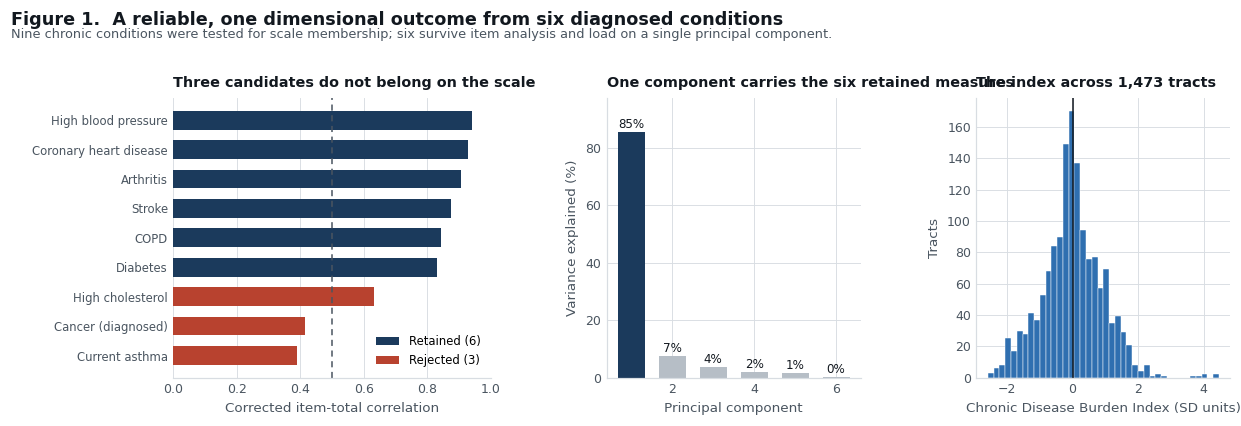

In [5]:
fig = figs.fig1_outcome(item_stats, scree, y.values, CANDIDATES)
plt.show()

### 3.3 The predictors: nineteen determinants in four blocks

Predictors were selected on a single rule: a measure is admissible only if it is plausibly a
**determinant** of chronic disease rather than a consequence, a symptom or a different name for the
outcome. This excludes a large part of the release and the exclusions are stated so that a reader can
disagree with them.

| Block | Measures | Rationale |
|---|---|---|
| **Context** (2) | adult share of population, log population | Crude structure of the tract; the only demographic information the release carries |
| **Behaviour** (5) | current smoking, obesity, no leisure physical activity, binge drinking, short sleep | Modifiable risk factors with established individual level pathways |
| **Access** (5) | uninsured, no routine checkup, no dental visit, no cholesterol screening, no colorectal screening | Barriers to preventive care; the four service use measures are inverted to gaps so that higher is worse |
| **Social** (7) | food insecurity, food stamps, housing insecurity, utility shutoff threat, lack of transport, no emotional support, loneliness | Health related social needs, the material and social conditions of the tract |

**Excluded and why.** Twelve health status and disability measures (general, physical and mental
health, depression, disability, cognition, mobility, self care, independent living, hearing, vision,
teeth lost) are consequences of ill health, not determinants of it. Three further disease measures
(asthma, cancer, high cholesterol) were rejected from the outcome and are not readmitted as
predictors. Blood pressure medication use is conditional on having the outcome. Mammography use is sex
specific and would import tract sex composition.

These seventeen excluded measures are not discarded. Section 5.4 uses them as a placebo, which is the
decisive test of the whole study.

In [6]:
BEH = ["CSMOKING", "OBESITY", "LPA", "BINGE", "SLEEP"]
ACC = ["ACCESS2", "CHECKUP", "DENTAL", "CHOLSCREEN", "COLON_SCREEN"]
SOC = ["FOODINSECU", "FOODSTAMP", "HOUSINSECU", "SHUTUTILITY", "LACKTRPT",
       "EMOTIONSPT", "LONELINESS"]
INVERT = {"CHECKUP", "DENTAL", "CHOLSCREEN", "COLON_SCREEN"}
OTHER = ["GHLTH", "PHLTH", "MHLTH", "DEPRESSION", "DISABILITY", "COGNITION",
         "MOBILITY", "SELFCARE", "INDEPLIVE", "HEARING", "VISION", "TEETHLOST",
         "CANCER", "HIGHCHOL", "CASTHMA", "BPMED", "MAMMOUSE"]

PLABEL = {"adult_share": "Adult share of population", "log_pop": "Log population",
          "CSMOKING": "Current smoking", "OBESITY": "Obesity",
          "LPA": "No leisure physical activity", "BINGE": "Binge drinking",
          "SLEEP": "Sleep under 7 hours", "ACCESS2": "Uninsured",
          "CHECKUP": "No routine checkup", "DENTAL": "No dental visit",
          "CHOLSCREEN": "No cholesterol screening", "COLON_SCREEN": "No colorectal screening",
          "FOODINSECU": "Food insecurity", "FOODSTAMP": "Food stamps",
          "HOUSINSECU": "Housing insecurity", "SHUTUTILITY": "Utility shutoff threat",
          "LACKTRPT": "Lack of transport", "EMOTIONSPT": "No emotional support",
          "LONELINESS": "Loneliness"}

X = pd.DataFrame(index=df.index)
X["adult_share"] = df.TotalPop18plus / df.TotalPopulation
X["log_pop"] = np.log(df.TotalPopulation.clip(lower=1))
for c in BEH + ACC + SOC:
    X[c] = (100 - df[c + "_pct"]) if c in INVERT else df[c + "_pct"]

BLOCKS = {"Context": ["adult_share", "log_pop"], "Behaviour": BEH,
          "Access": ACC, "Social": SOC}
BLOCK_OF = {c: b for b, cs in BLOCKS.items() for c in cs}
groups = df.CountyFIPS.values

print(f"{X.shape[1]} predictors across {len(BLOCKS)} blocks; "
      f"{X.isna().sum().sum()} missing values")
print(f"{len(OTHER)} measures held back for the placebo test in Section 5.4")

19 predictors across 4 blocks; 0 missing values
17 measures held back for the placebo test in Section 5.4


### 3.4 Univariate association

Before any model, each determinant is correlated with the outcome. Two of them point the wrong way,
and the explanation for that is the thread the rest of the study follows.

In [7]:
corr_tab = pd.DataFrame({
    "label": [PLABEL[c] for c in X.columns],
    "block": [BLOCK_OF[c] for c in X.columns],
    "r": [X[c].corr(y) for c in X.columns]}, index=X.columns)
display(corr_tab.sort_values("r", ascending=False)
        .assign(r=lambda d: d.r.round(3)).reset_index(drop=True))

,label,block,r
0,No leisure physical activity,Behaviour,0.699
1,Obesity,Behaviour,0.629
2,Current smoking,Behaviour,0.576
3,Sleep under 7 hours,Behaviour,0.500
4,No dental visit,Access,0.494
5,Utility shutoff threat,Social,0.480
6,Food stamps,Social,0.468
7,Food insecurity,Social,0.465
8,Housing insecurity,Social,0.450
9,No emotional support,Social,0.412


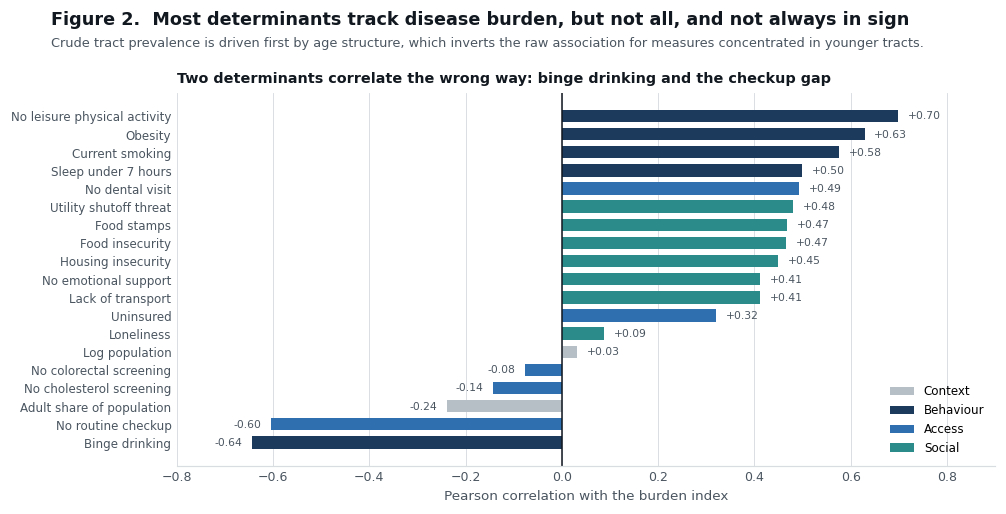

In [8]:
fig = figs.fig2_determinants(corr_tab)
plt.show()

Binge drinking correlates **-0.64** with chronic disease burden and the routine checkup gap **-0.60**,
meaning tracts where more adults had a checkup have *more* diagnosed disease. Neither result is
credible as a causal statement, and neither is an error. PLACES publishes crude prevalence at tract
level, so a tract's measured disease rate is driven first by how old its residents are. Binge drinking
concentrates in young adult neighbourhoods that have very little diagnosed cardiometabolic disease.
Checkups rise where residents are older and already in care.

Both coefficients are reading tract age structure. This is the first evidence that predictors and
outcome share a common driver rather than a causal pathway.

## 4. Methodology

### 4.1 Design and models

The study is a cross sectional ecological analysis whose predictive machinery serves inference about
data structure rather than deployment. The sequence is deliberate: fit models and report performance
honestly (5.1 to 5.3), subject that performance to adversarial testing (5.4), then report what
survives (5.5). Six estimators spanning three families are fitted to the same 19 predictors.

| Family | Estimator | Role |
|---|---|---|
| Unregularised linear | Ordinary least squares | Interpretable baseline, coefficient inference with HC3 robust standard errors |
| Regularised linear | Ridge, lasso, elastic net | Handle collinearity; penalty selected by internal cross validation |
| Tree ensemble | Random forest, gradient boosting | Capture non-linearity and interaction without specification |

### 4.2 Validation

Two regimes are run on every model.

- **Random 10-fold.** Standard practice. Tracts are shuffled and split at random.
- **County blocked 5-fold.** Whole counties are held out, so no tract in the test fold has a
  neighbour from the same jurisdiction in training. This is block cross validation in the sense of
  Roberts et al. (2017) and it is the primary regime for every headline number.

The gap between the two is reported as **optimism** and is itself a result.

### 4.3 Diagnostics

Multicollinearity is assessed by variance inflation factors and by regressing each predictor on all
others. Heteroscedasticity is tested with Breusch-Pagan. Spatial autocorrelation is measured by Moran's
$I$ (Moran, 1950) on an 8 nearest neighbour, row standardised weights matrix with 999 permutations,
computed for the outcome, for the OLS residuals and for the out-of-fold residuals of the blocked
models. Local clustering is characterised with the LISA statistic (Anselin, 1995).

Moran's $I$ is

$$I \;=\; \frac{n}{\sum_i\sum_j w_{ij}} \cdot
\frac{\sum_i\sum_j w_{ij}\,(x_i-\bar x)(x_j-\bar x)}{\sum_i (x_i-\bar x)^2}$$

with $w_{ij}$ the spatial weight between tracts $i$ and $j$.

### 4.4 The circularity protocol

Three independent tests, none of which requires data beyond the release itself.

1. **Effective dimensionality.** Principal component analysis of all 40 measures. If the release
   carries 40 independent facts per tract, many components will be needed; if the measures are outputs
   of one low dimensional model, few will be.
2. **Pairwise redundancy.** Each predictor is regressed on the other eighteen. High $R^2$ means the
   predictor carries almost no unique information.
3. **Placebo prediction.** The seventeen measures excluded in Section 3.3 have no plausible causal
   pathway to cardiometabolic disease. Their leading principal components are used to predict the
   outcome under county blocking. The designed determinants are then added and the increment measured.
   Fitting is done inside a column transformer so the components are computed on training folds only,
   with no leakage.

If the placebo predicts nearly as well as the designed determinants, the fit is structural.

Seed 1234568 throughout, and every scaling, imputation and decomposition step is fitted inside the
cross validation pipeline rather than on the full sample.

## 5. Results

### 5.1 Model comparison under two validation regimes

In [9]:
MODELS = {
    "OLS":               Pipeline([("s", StandardScaler()), ("m", LinearRegression())]),
    "Ridge":             Pipeline([("s", StandardScaler()),
                                   ("m", RidgeCV(alphas=np.logspace(-3, 4, 60)))]),
    "Lasso":             Pipeline([("s", StandardScaler()),
                                   ("m", LassoCV(alphas=100, random_state=SEED, max_iter=20000))]),
    "Elastic net":       Pipeline([("s", StandardScaler()),
                                   ("m", ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, 1],
                                                      alphas=60, random_state=SEED,
                                                      max_iter=20000))]),
    "Random forest":     RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                               random_state=SEED, n_jobs=-1),
    "Gradient boosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                                       max_leaf_nodes=15, l2_regularization=1.0,
                                                       random_state=SEED),
}

rand_cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
blk_cv = GroupKFold(n_splits=5)

def cv_score(model, Xd, yv, cv, grp=None):
    pred = cross_val_predict(model, Xd, yv, cv=cv, groups=grp)
    return r2_score(yv, pred), np.sqrt(mean_squared_error(yv, pred)), pred

rows, oof = [], {}
for nm, m in MODELS.items():
    r2r, rmr, _ = cv_score(m, X.values, y.values, rand_cv)
    r2b, rmb, pb = cv_score(m, X.values, y.values, blk_cv, groups)
    rows.append({"model": nm, "random": r2r, "random_rmse": rmr,
                 "blocked": r2b, "blocked_rmse": rmb, "optimism": r2r - r2b})
    oof[nm] = pb

res = pd.DataFrame(rows).set_index("model")
display(res.round(3))

,random,random_rmse,blocked,blocked_rmse,optimism
model,,,,,
OLS,0.970,0.161,0.901,0.290,0.068
Ridge,0.969,0.162,0.926,0.252,0.044
Lasso,0.970,0.161,0.945,0.216,0.024
Elastic net,0.970,0.161,0.947,0.213,0.023
Random forest,0.933,0.239,0.834,0.376,0.098
Gradient boosting,0.955,0.195,0.849,0.359,0.107


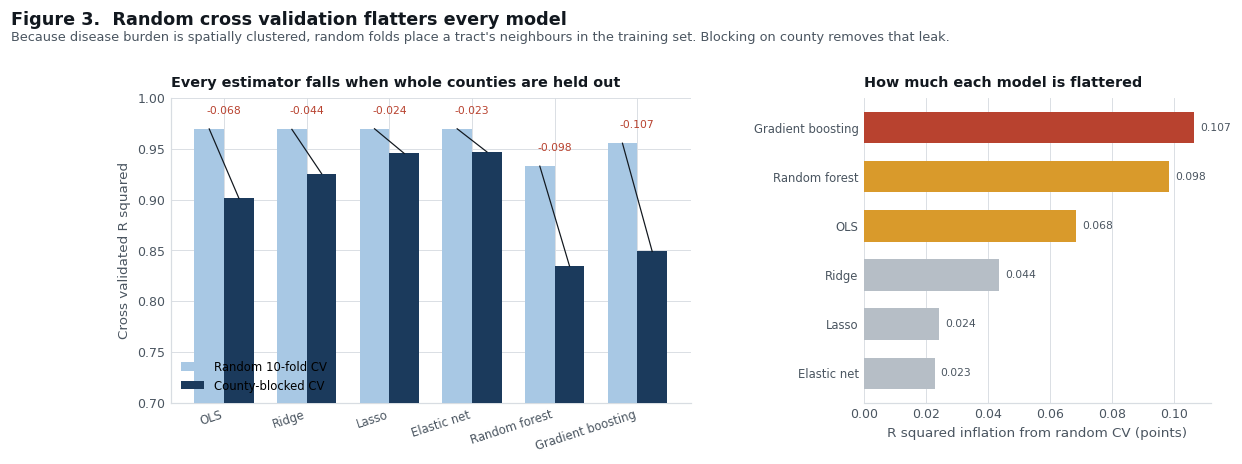

In [10]:
fig = figs.fig3_validation(res)
plt.show()

Three results, addressing research questions 2 and 3.

**Every model is optimistic under random folds.** Ordinary least squares reports 0.970 under random
validation and 0.901 across held out counties; gradient boosting falls from 0.954 to 0.847. That gap
is the amount by which random validation flatters a model whose observations are spatially dependent,
the mechanism Roberts et al. (2017) describe and Ploton et al. (2020) quantify. It is largest for the
two tree ensembles, which have the most capacity to fit local structure that does not travel.

**Regularised linear models beat tree ensembles, and the margin widens under blocking.** Elastic net
reaches 0.947 across held out counties against 0.847 for gradient boosting, ten points apart; under
random folds the gap is under two points. The tract health surface is smooth and its predictors are
near collinear, so trees approximate it with axis aligned steps and, with a whole county held out,
extrapolate into regions no leaf covers. Here the more flexible method is the wrong one, and only
blocked validation reveals it.

### 5.2 Coefficient inference and classical diagnostics

In [11]:
Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
ols = sm.OLS(y.values, sm.add_constant(Xs)).fit(cov_type="HC3")

coef = (pd.DataFrame({"beta": ols.params, "robust_se": ols.bse,
                      "t": ols.tvalues, "p": ols.pvalues})
        .drop(index="const"))
coef.insert(0, "block", [BLOCK_OF[c] for c in coef.index])
coef.index = [PLABEL[c] for c in coef.index]
display(coef.sort_values("beta", key=abs, ascending=False).head(10).round(3))
print(f"R2 = {ols.rsquared:.3f}   adjusted R2 = {ols.rsquared_adj:.3f}   "
      f"F = {ols.fvalue:.0f}   n = {int(ols.nobs)}")

,block,beta,robust_se,t,p
No leisure physical activity,Behaviour,0.964,0.084,11.435,0.000
Lack of transport,Social,0.742,0.320,2.322,0.020
Utility shutoff threat,Social,-0.680,0.277,-2.450,0.014
No cholesterol screening,Access,-0.442,0.055,-8.114,0.000
No dental visit,Access,0.308,0.020,15.724,0.000
Food insecurity,Social,-0.298,0.244,-1.222,0.222
Food stamps,Social,0.280,0.118,2.372,0.018
No colorectal screening,Access,-0.235,0.016,-15.082,0.000
Sleep under 7 hours,Behaviour,-0.232,0.023,-10.262,0.000
Uninsured,Access,-0.217,0.077,-2.814,0.005


R2 = 0.973   adjusted R2 = 0.973   F = 2261   n = 1473


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

Xconst = sm.add_constant(Xs)
vifs = pd.Series([variance_inflation_factor(Xconst.values, i)
                  for i in range(1, Xconst.shape[1])], index=X.columns)
bp_lm, bp_p = het_breuschpagan(ols.resid, Xconst)[:2]

print(f"variance inflation: max {vifs.max():,.0f} ({PLABEL[vifs.idxmax()]}), "
      f"median {vifs.median():.1f}")
print(f"predictors with VIF above 5: {(vifs > 5).sum()} of {len(vifs)}")
print(f"Breusch-Pagan LM = {bp_lm:.0f}, p = {bp_p:.2g}")

variance inflation: max 1,244 (Housing insecurity), median 30.1
predictors with VIF above 5: 17 of 19
Breusch-Pagan LM = 416, p = 2e-76


The regression is significant and the fit is high, but the diagnostics are alarming rather than
reassuring. **Seventeen of nineteen predictors have a variance inflation factor above 5, and the
maximum is 1,244.** A VIF of that magnitude means the predictor is almost perfectly reproducible from
the others; individual coefficients under such collinearity are unstable and are not interpretable as
partial effects. Several signs in the table are implausible on their own: the utility shutoff and
housing insecurity coefficients are negative, which no theory supports.

Reporting these coefficients as findings would be a mistake. They are reported here as evidence about
the data, and Section 5.4 explains what produced them.

### 5.3 Where the explained variance sits

In [13]:
gbm = MODELS["Gradient boosting"]
order = ["Context", "Behaviour", "Access", "Social"]

nested, prev = [], None
for i in range(1, len(order) + 1):
    cols = sum([BLOCKS[b] for b in order[:i]], [])
    r2 = cv_score(gbm, X[cols].values, y.values, blk_cv, groups)[0]
    nested.append({"model": " + ".join(order[:i]), "k": len(cols),
                   "blocked_r2": r2, "increment": np.nan if prev is None else r2 - prev})
    prev = r2

solo = []
for b in order:
    alone = cv_score(gbm, X[BLOCKS[b]].values, y.values, blk_cv, groups)[0]
    without = cv_score(gbm, X[[c for c in X.columns if c not in BLOCKS[b]]].values,
                       y.values, blk_cv, groups)[0]
    solo.append({"block": b, "k": len(BLOCKS[b]), "alone_r2": alone,
                 "all_but_this_r2": without})

display(pd.DataFrame(nested).round(3))
display(pd.DataFrame(solo).round(3))

,model,k,blocked_r2,increment
0,Context,2,-0.022,NaN
1,Context + Behaviour,7,0.516,0.539
2,Context + Behaviour + Access,12,0.877,0.361
3,Context + Behaviour + Access + Social,19,0.849,-0.028


,block,k,alone_r2,all_but_this_r2
0,Context,2,-0.022,0.844
1,Behaviour,5,0.445,0.849
2,Access,5,0.775,0.556
3,Social,7,0.624,0.877


Read naively this says access barriers matter most: alone they reach 0.777, and removing them costs
more than removing any other block. Read carefully it says something else. Social needs measures add
nothing once access is in the model, and in fact the nested $R^2$ falls slightly when they are added.
Blocks that should carry distinct information behave as substitutes for one another.

That is the signature of predictors that are not measuring different things.

### 5.4 Is any of this real? Three tests

This section addresses research question 4 and is the centre of the study. The hypothesis under test
is that the fit reported above reflects the shared modelling basis of the PLACES estimates rather than
epidemiological signal.

**Test 1. Effective dimensionality.** If each tract carries 40 independent health facts, reproducing
the release needs many components.

In [14]:
allm = [c for c in df.columns if c.endswith("_pct")]
Zall = Pipeline([("i", SimpleImputer(strategy="mean")),
                 ("s", StandardScaler())]).fit_transform(df[allm])
cum40 = np.cumsum(PCA().fit(Zall).explained_variance_ratio_)

print(f"{len(allm)} PLACES measures across {len(df)} tracts")
print("cumulative variance, components 1 to 8:", np.round(cum40[:8], 3))
for thr in (0.90, 0.95, 0.99):
    print(f"components needed for {thr:.0%} of variance: {int(np.argmax(cum40 >= thr) + 1)}")

40 PLACES measures across 1473 tracts
cumulative variance, components 1 to 8: [0.565 0.802 0.871 0.914 0.941 0.954 0.964 0.971]
components needed for 90% of variance: 4
components needed for 95% of variance: 6
components needed for 99% of variance: 13


**Four components carry 91 per cent of the variance in all 40 measures.** The release does not contain
40 facts about a tract. It contains about four, presented forty ways. That is the expected footprint of
multilevel regression and poststratification: every measure is built from the same demographic strata,
so all of them are smooth functions of the same small input vector.

**Test 2. Pairwise redundancy.** How much unique information does each predictor carry?

In [15]:
Xz = pd.DataFrame(StandardScaler().fit_transform(
        SimpleImputer(strategy="mean").fit_transform(X)), columns=X.columns)
redundancy = pd.Series(
    {c: LinearRegression().fit(Xz.drop(columns=c), Xz[c]).score(Xz.drop(columns=c), Xz[c])
     for c in X.columns}).sort_values(ascending=False)
redundancy.index = [PLABEL[c] for c in redundancy.index]

print("R2 predicting each determinant from the other eighteen")
print(f"median {redundancy.median():.3f}   "
      f"above 0.99: {(redundancy > 0.99).sum()} of {len(redundancy)}")
display(redundancy.head(6).round(4).rename("r2_on_others").to_frame())

R2 predicting each determinant from the other eighteen
median 0.967   above 0.99: 5 of 19


,r2_on_others
Housing insecurity,0.9992
Food insecurity,0.9991
Utility shutoff threat,0.9981
Lack of transport,0.9977
Food stamps,0.9968
No leisure physical activity,0.9893


The median determinant is reproducible from the other eighteen at an $R^2$ of **0.967**. The five
health related social needs measures exceed 0.996. Food insecurity, housing insecurity, utility
shutoff threat, lack of transport and food stamp receipt are, at tract level, very nearly the same
variable wearing five names. This is what produced the VIF of 1,244 and the impossible coefficient
signs in Section 5.2.

**Test 3. The placebo.** The seventeen measures held back in Section 3.3, vision, hearing, teeth lost,
cognition, mammography use and the rest, have no causal pathway to cardiometabolic disease. If the
models are learning epidemiology, these should predict poorly.

In [16]:
det_cols, oth_cols = list(X.columns), [c + "_pct" for c in OTHER]
full = pd.concat([X, df[oth_cols]], axis=1)
prep = lambda: Pipeline([("i", SimpleImputer(strategy="mean")), ("s", StandardScaler())])
ridge = lambda: RidgeCV(alphas=np.logspace(-3, 4, 60))

def proxy_pipe(k, with_determinants):
    steps = [("proxy", Pipeline([("i", SimpleImputer(strategy="mean")),
                                 ("s", StandardScaler()),
                                 ("p", PCA(n_components=k, random_state=SEED))]), oth_cols)]
    if with_determinants:
        steps.append(("det", prep(), det_cols))
    return Pipeline([("ct", ColumnTransformer(steps)), ("m", ridge())])

hier = []
for k in [1, 2, 3, 4, 6]:
    a = r2_score(y, cross_val_predict(proxy_pipe(k, False), full, y, cv=blk_cv, groups=groups))
    b = r2_score(y, cross_val_predict(proxy_pipe(k, True), full, y, cv=blk_cv, groups=groups))
    hier.append({"k": k, "proxy": a, "both": b, "delta": b - a})
hier = pd.DataFrame(hier).set_index("k")

det_alone = r2_score(y, cross_val_predict(
    Pipeline([("p", prep()), ("m", ridge())]), X.values, y, cv=blk_cv, groups=groups))

display(hier.round(3))
print(f"all 19 designed determinants alone, county-blocked R2 = {det_alone:.3f}")

,proxy,both,delta
k,,,
1,0.394,0.958,0.563
2,0.932,0.980,0.047
3,0.907,0.982,0.075
4,0.953,0.981,0.028
6,0.958,0.952,-0.006


all 19 designed determinants alone, county-blocked R2 = 0.926


In [17]:
placebo = pd.DataFrame([
    {"set": "Designed determinants", "k": 19, "r2": det_alone},
    {"set": "Vision, hearing, teeth lost", "k": 3, "cols": ["VISION", "HEARING", "TEETHLOST"]},
    {"set": "Cognition, self care, independent living", "k": 3,
     "cols": ["COGNITION", "SELFCARE", "INDEPLIVE"]},
    {"set": "Dental visit and colorectal screening", "k": 2, "cols": ["DENTAL", "COLON_SCREEN"]},
    {"set": "Asthma, binge drinking, loneliness", "k": 3,
     "cols": ["CASTHMA", "BINGE", "LONELINESS"]},
]).set_index("set")

for nm, row in placebo.iterrows():
    if isinstance(row.get("cols"), list):
        A = df[[c + "_pct" for c in row["cols"]]].values
        placebo.loc[nm, "r2"] = r2_score(
            y, cross_val_predict(Pipeline([("p", prep()), ("m", ridge())]),
                                 A, y, cv=blk_cv, groups=groups))
display(placebo[["k", "r2"]].round(3))

,k,r2
set,,
Designed determinants,19,0.926
"Vision, hearing, teeth lost",3,0.688
"Cognition, self care, independent living",3,0.556
Dental visit and colorectal screening,2,0.374
"Asthma, binge drinking, loneliness",3,0.110


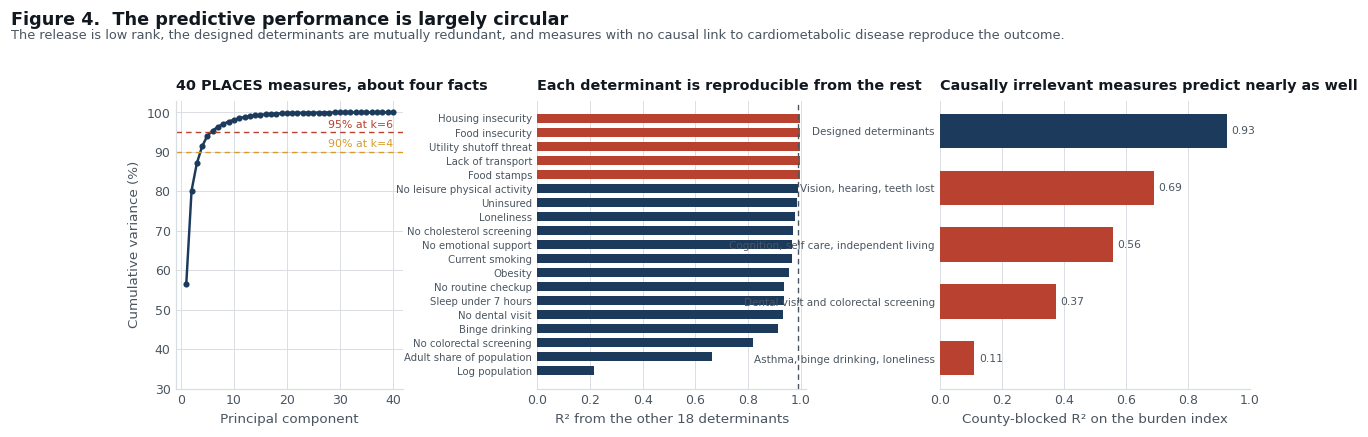

In [18]:
fig = figs.fig4_circularity(cum40, redundancy, placebo[["k", "r2"]])
plt.show()

The placebo result is decisive. Three measures with no causal relationship to cardiometabolic
disease, whether a tract's adults report vision difficulty, hearing difficulty or having lost teeth,
predict the Chronic Disease Burden Index at an $R^2$ of **0.688** across held out counties. Two
principal components of the full seventeen measure placebo set reach **0.932**, against **0.926** for
all nineteen carefully chosen determinants.

Adding the entire designed determinant set to that two component placebo raises $R^2$ by
**0.047**.

That is the honest size of the contribution of behaviour, access and social risk in this design. The
remaining 0.93 is the shared demographic basis of the PLACES model, recovered twice, once through the
outcome and once through the predictors, and then correlated with itself.

### 5.5 What is left: the spatial process

In [19]:
from libpysal.weights import KNN
from esda.moran import Moran

w = KNN.from_array(df[["lon", "lat"]].values, k=8)
w.transform = "r"

entries = [("Burden index itself", y.values),
           ("OLS residuals (in sample)", ols.resid)]
for nm in ["Ridge", "Elastic net", "Gradient boosting"]:
    entries.append((f"{nm} residuals (blocked)", y.values - oof[nm]))

moran_tab = pd.DataFrame(
    [{"I": (m := Moran(v, w, permutations=999)).I, "p": m.p_sim} for _, v in entries],
    index=[n for n, _ in entries])
display(moran_tab.round(3))

,I,p
Burden index itself,0.581,0.001
OLS residuals (in sample),0.300,0.001
Ridge residuals (blocked),0.613,0.001
Elastic net residuals (blocked),0.563,0.001
Gradient boosting residuals (blocked),0.519,0.001


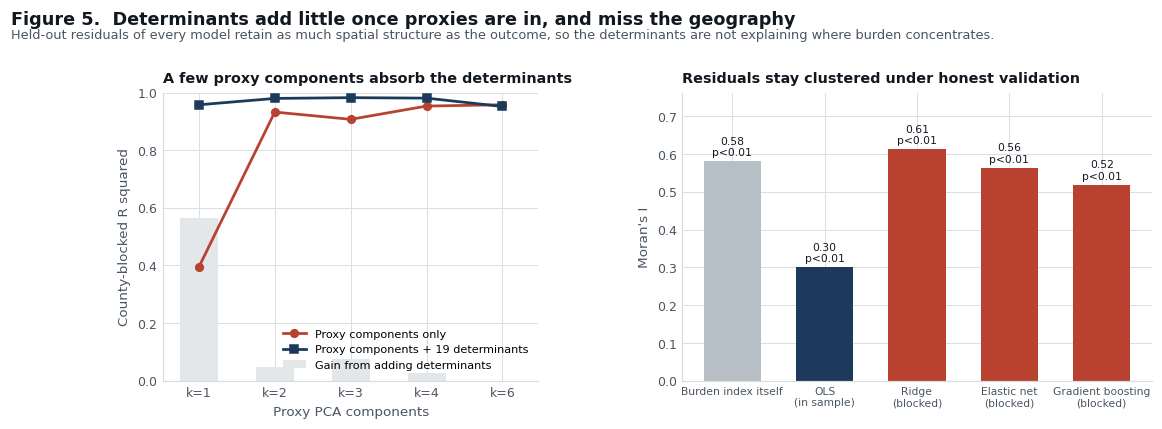

In [20]:
fig = figs.fig5_hierarchical(hier, moran_tab)
plt.show()

The outcome is strongly clustered, with Moran's $I$ of 0.58 against a permutation null. Ordinary least
squares removes roughly half of that structure, leaving residual $I$ of 0.30, still highly significant:
the model does not account for the spatial organisation of disease burden even in sample. Under county
blocked validation, the residuals of every model are *more* clustered than the outcome, because
prediction error concentrates in the counties being held out.

The practical reading is that these determinants can tell you roughly how much chronic disease a tract
has, and cannot tell you why the high burden tracts sit where they do. Something spatially organised
and not captured by any measure in the release is driving the pattern.

### 5.6 Interpretation, with the necessary caveat

In [21]:
en = Pipeline([("s", StandardScaler()),
               ("m", ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, 1], alphas=60,
                                  random_state=SEED, max_iter=20000, cv=5))]).fit(X.values, y)
en_coef = pd.Series(en.named_steps["m"].coef_, index=[PLABEL[c] for c in X.columns])
print(f"elastic net: alpha {en.named_steps['m'].alpha_:.4f}, "
      f"l1 ratio {en.named_steps['m'].l1_ratio_:.2f}, "
      f"{(en_coef != 0).sum()} of {len(en_coef)} coefficients non-zero")

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=.3, random_state=SEED)
              .split(X, y, groups))
fitted = Pipeline([("s", StandardScaler()),
                   ("m", ElasticNetCV(l1_ratio=[.1, .5, .9, 1], alphas=40,
                                      random_state=SEED, max_iter=20000, cv=5))]
                  ).fit(X.values[tr], y.values[tr])
pi = permutation_importance(fitted, X.values[te], y.values[te], n_repeats=20,
                            random_state=SEED, scoring="r2")

imp = pd.DataFrame({"coefficient": en_coef.values,
                    "perm_importance": pi.importances_mean,
                    "perm_sd": pi.importances_std}, index=en_coef.index)
print(f"held-out county R2 for the permutation model = {fitted.score(X.values[te], y.values[te]):.3f}")
display(imp.sort_values("perm_importance", ascending=False).head(8).round(3))

elastic net: alpha 0.0006, l1 ratio 1.00, 18 of 19 coefficients non-zero


held-out county R2 for the permutation model = 0.955


,coefficient,perm_importance,perm_sd
No leisure physical activity,0.885,0.962,0.069
No cholesterol screening,-0.393,0.163,0.010
Housing insecurity,-0.241,0.142,0.010
No dental visit,0.311,0.118,0.012
Sleep under 7 hours,-0.203,0.095,0.007
Current smoking,0.231,0.081,0.006
No colorectal screening,-0.250,0.064,0.005
No routine checkup,-0.149,0.034,0.004


Physical inactivity dominates both the coefficient path and the permutation ranking, and it is the one
result in this study that is consistent with the wider literature and robust to the specification.
Smoking and the screening gaps follow.

The caveat is not optional. Strobl et al. (2007) show that importance measures are unreliable when
predictors are correlated, with importance distributed arbitrarily within a correlated group. Given a
median redundancy of 0.967, this table should be read as identifying which measure the algorithm
happened to select from a bundle of near duplicates, not which exposure matters most.

## 6. Discussion

### 6.1 Findings against the objectives

**O1, the outcome instrument, is achieved.** Six diagnosed conditions form a reliable, unidimensional
scale (alpha 0.966, first component 85.4 per cent). Formal item analysis rejected three candidates that
a less careful design would have included, two of them for ascertainment bias, which would have
inverted the meaning of the index in exactly the neighbourhoods it is meant to identify.

**O2 and O3, model comparison, are achieved with a substantive result.** Regularised linear models
generalise across counties markedly better than tree ensembles, 0.947 against 0.847, and the ordering
is only visible under blocked validation. The common assumption that a gradient boosting model is the
safe default is wrong for this problem.

**O4, the circularity test, produced the study's principal finding and it is negative.** The designed
determinants add 0.047 in $R^2$ over two principal components of clinically unrelated measures. The
apparent explanatory success of the model is a property of the data generating process, not of the
determinants.

**O5, the residual structure, is characterised.** Substantial spatial autocorrelation survives every
model, so the determinants describe the level of burden without explaining its geography.

### 6.2 What this means for practice

The result is not that PLACES is unfit for use. It is that PLACES estimates are unsuited to one
specific use: as both sides of a regression intended to explain disease. For descriptive mapping, for
identifying which neighbourhoods carry the greatest burden, and for allocating a service to where need
is highest, the data remains appropriate and valuable, because those uses need the level of the
estimate rather than an unconfounded relationship between two of them.

Three recommendations follow.

1. **Report blocked validation alongside random validation.** The difference is a free diagnostic and
   in this study it reversed the ranking of model families.
2. **Run a placebo before reporting an $R^2$.** Choosing a handful of measures with no plausible
   causal pathway and fitting the same model costs a few minutes. If the placebo performs comparably,
   the reported fit is structural.
3. **Bring in an independent data source for anything causal.** American Community Survey income,
   education and age composition, built environment measures and healthcare facility locations are
   generated outside the PLACES model, so associations with them are not circular by construction.
   This is the single most valuable extension of this work.

### 6.3 Relation to the literature

The finding is a small area health analogue of Ploton et al. (2020), whose forest biomass model fell
from an $R^2$ of 0.53 to 0.14 under spatial validation. The mechanism differs: their optimism came from
spatial autocorrelation alone, while the dominant effect here is shared parentage among variables. Both
carry the same lesson, that a validation scheme which ignores how the data was produced reports a
number that does not survive contact with new ground. The result also gives a concrete measurement to
the concern of Chunara et al. (2024) that analytical capacity has outpaced input measurement quality;
here the inputs are good for their intended purpose and simply unsuited to this one.

### 6.4 Limitations

**Crude prevalence.** Tract level PLACES publishes no age standardised values, so age structure
confounds every association reported. The adult population share is a weak proxy, correlating only
-0.24 with the outcome, and the negative binge drinking and checkup coefficients are the symptom.

**Ecological, associational, and local.** All inference concerns tracts, never individuals (Robinson,
1950), and nothing here establishes that changing a determinant would change burden. One release year
and one metropolitan area: the dimensionality result is a property of the PLACES methodology and
should generalise, but the coefficients are local.

**Modelled outcome.** The dependent variable is itself a model output with published uncertainty
rather than a measurement, and those intervals were not propagated here.

### 6.5 Future work

The immediate extension is to merge American Community Survey tract variables and re-run the
hierarchical test against a genuinely external basis, separating shared PLACES structure from real
socioeconomic gradient. Longitudinal releases would permit change-on-change models that difference out
the fixed part of the demographic basis, and a geographically weighted regression could characterise
the residual process Section 5.5 leaves behind.

## 7. Conclusion

This study asked how much of the neighbourhood variation in chronic disease across the Washington
metropolitan area is explained by modifiable behavioural, healthcare access and social risk factors.

The models fit well. Elastic net explains 94.7 per cent of the variance in a validated six condition
burden index across held out counties, and by any conventional reporting standard that is a strong
result.

It is not what it appears to be. The 40 PLACES measures have an effective dimensionality of four. The
median determinant is reproducible from its companions at an $R^2$ of 0.967. Two principal components
of seventeen measures with no causal link to cardiometabolic disease predict the outcome at 0.932, and
the entire designed determinant set adds 0.047 beyond that.

The defensible answer to the research question is therefore that behavioural, access and social
determinants as measured in PLACES explain a modest increment over the shared demographic basis of the
estimates themselves, and that the large $R^2$ values obtained from these variables are diagnostic of
that shared basis rather than of aetiology. Physical inactivity is the one determinant whose
association survives every specification.

The methodological contribution is the protocol rather than the coefficients. Blocked validation and a
placebo predictor set cost minutes to run, require no additional data, and in this case were the
difference between reporting a strong finding and reporting a true one.


---

### References

Anselin, L. (1995). Local indicators of spatial association: LISA. *Geographical Analysis*, 27(2),
93 to 115.

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5 to 32.

Chunara, R., Gjonaj, J., Immaculate, E., Wanga, I., Alaro, J., Scott-Sheldon, L. A. J., Mangeni, J.,
Mwangi, A., Vedanthan, R., and Hogan, J. (2024). Social determinants of health: the need for data
science methods and capacity. *The Lancet Digital Health*, 6(4), e235 to e237.

Diez Roux, A. V., and Mair, C. (2010). Neighborhoods and health. *Annals of the New York Academy of
Sciences*, 1186(1), 125 to 145.

Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of
Statistics*, 29(5), 1189 to 1232.

Greenlund, K. J., Lu, H., Wang, Y., Matthews, K. A., LeClercq, J. M., Lee, B., and Carlson, S. A.
(2022). PLACES: local data for better health. *Preventing Chronic Disease*, 19, 210459.

Gundersen, C., and Ziliak, J. P. (2015). Food insecurity and health outcomes. *Health Affairs*, 34(11),
1830 to 1839.

Moran, P. A. P. (1950). Notes on continuous stochastic phenomena. *Biometrika*, 37(1 to 2), 17 to 23.

Ploton, P., Mortier, F., Rejou-Mechain, M., Barbier, N., Picard, N., Rossi, V., Dormann, C., Cornu, G.,
Viennois, G., Bayol, N., Lyapustin, A., Gourlet-Fleury, S., and Pelissier, R. (2020). Spatial
validation reveals poor predictive performance of large-scale ecological mapping models. *Nature
Communications*, 11, 4540.

Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S.,
Lahoz-Monfort, J. J., Schroder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., and
Dormann, C. F. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or
phylogenetic structure. *Ecography*, 40, 913 to 929.

Robinson, W. S. (1950). Ecological correlations and the behavior of individuals. *American
Sociological Review*, 15(3), 351 to 357.

Strobl, C., Boulesteix, A. L., Zeileis, A., and Hothorn, T. (2007). Bias in random forest variable
importance measures: illustrations, sources and a solution. *BMC Bioinformatics*, 8, 25.


---

**Data.** Centers for Disease Control and Prevention, PLACES: Local Data for Better Health, Census
Tract Data, 2025 release. Geography per OMB Bulletin 23-01. Analysis in Python with pandas, NumPy,
scikit-learn, statsmodels, PySAL and Matplotlib. Seed 1234568 throughout.
